# PK/PD Exercises — Solutions

> **Instructor copy.** Share after the review session, not before.

# PK/PD Take-Home Exercises

> **Before running anything, read this.**
>
> 1. **R**: Download from https://cran.r-project.org (version 4.2+)
> 2. **R kernel for Jupyter**: In an R console run:
>    ```r
>    install.packages("IRkernel")
>    IRkernel::installspec()
>    ```
>    Then restart Jupyter and select R as the kernel.
> 3. **Packages**: Run the Setup cell below. It tries `renv` first and falls back to `install.packages()` automatically.
>
> Questions? Send them over.

In [1]:
# Package setup — run this first
setup_ok <- tryCatch({
  if (!requireNamespace("renv", quietly = TRUE))
    install.packages("renv", repos = "https://cloud.r-project.org")
  renv::restore(prompt = FALSE)
  TRUE
}, error = function(e) {
  message("renv failed, using install.packages() instead...")
  FALSE
})

if (!setup_ok) {
  needed  <- c("ggplot2", "dplyr", "nlme", "deSolve", "gridExtra")
  missing <- needed[!sapply(needed, requireNamespace, quietly = TRUE)]
  if (length(missing) > 0)
    install.packages(missing, repos = "https://cloud.r-project.org")
}

library(ggplot2)
library(dplyr)
options(repr.plot.width = 9, repr.plot.height = 4)
cat("Ready.\n")

- The library is already synchronized with the lockfile.



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Ready.


In [2]:
# Helper functions — do not modify

pk_oral <- function(t, dose, ka, CL, V, F = 1) {
  ke <- CL / V
  if (abs(ka - ke) < 1e-6) ka <- ka * 1.0001
  (F * dose * ka) / (V * (ka - ke)) * (exp(-ke * t) - exp(-ka * t))
}

one_comp_oral <- function(Time, Dose, ka, CL, V) {
  ke <- CL / V
  (Dose * ka) / (V * (ka - ke)) * (exp(-ke * Time) - exp(-ka * Time))
}

pk_multidose <- function(t_vec, dose, ka, CL, V, interval, n_doses) {
  sapply(t_vec, function(t) {
    dose_times <- seq(0, (n_doses - 1) * interval, by = interval)
    total <- 0
    for (t0 in dose_times)
      if (t >= t0) total <- total + pk_oral(t - t0, dose, ka, CL, V)
    total
  })
}

emax_model <- function(C, Emax, EC50) Emax * C / (EC50 + C)

data(Theoph)
cat("Functions and data loaded.\n")

Functions and data loaded.


**Subject 1 parameters from the lecture (for reference):**

| Parameter | Value | Meaning |
|---|---|---|
| ka | 1.777 h⁻¹ | Absorption rate |
| CL | 0.0199 L/kg/h | Clearance |
| V | 0.369 L/kg | Volume of distribution |
| t½ | 12.8 h | Half-life |
| Tmax | ~2.0 h | Time to peak |

## Exercise 1: Fitting the PK Model to Subject 5

In the lecture we fitted Subject 1. Now fit the same model to **Subject 5**, who has noticeably different PK. The code structure is identical — you just need to fill in the subject number and starting value.

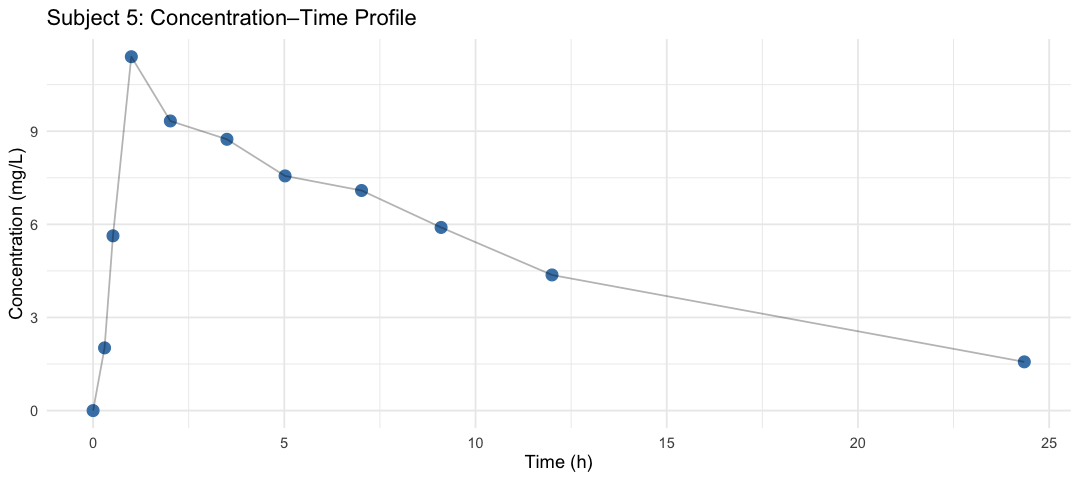

In [3]:
# Step 1: Extract and plot Subject 5's data
sub5 <- subset(Theoph, Subject == 5)   # SOLUTION: subject number = 5

ggplot(sub5, aes(x = Time, y = conc)) +
  geom_point(size = 3, color = "steelblue") +
  geom_line(alpha = 0.3) +
  labs(title = "Subject 5: Concentration–Time Profile",
       x = "Time (h)", y = "Concentration (mg/L)") +
  theme_minimal()

In [4]:
# Step 2: Fit the oral PK model
fit5 <- nls(
  conc ~ one_comp_oral(Time, Dose, ka, CL, V),
  data  = sub5,
  start = c(ka = 1.5, CL = 0.04, V = 0.5)   # SOLUTION: ka starting value = 1.5
)

summary(fit5)


Formula: conc ~ one_comp_oral(Time, Dose, ka, CL, V)

Parameters:
   Estimate Std. Error t value Pr(>|t|)    
ka 1.471488   0.435995   3.375 0.009713 ** 
CL 0.043604   0.007951   5.484 0.000585 ***
V  0.493063   0.063034   7.822 5.13e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.297 on 8 degrees of freedom

Number of iterations to convergence: 7 
Achieved convergence tolerance: 8.792e-06


In [5]:
# Step 3: Extract parameters and compare to Subject 1
p5    <- coef(fit5)
ke5   <- p5[["CL"]] / p5[["V"]]
half5 <- log(2) / ke5

cat("=== Subject 1 vs Subject 5 ===\n")
cat(sprintf("          Subj 1    Subj 5\n"))
cat(sprintf("  ka      1.777     %.3f   h-1\n",     p5[["ka"]]))
cat(sprintf("  CL      0.0199    %.4f  L/kg/h\n",   p5[["CL"]]))
cat(sprintf("  V       0.369     %.3f   L/kg\n",    p5[["V"]]))
cat(sprintf("  t1/2    12.8      %.1f    h\n",      half5))

=== Subject 1 vs Subject 5 ===
          Subj 1    Subj 5
  ka      1.777     1.471   h-1
  CL      0.0199    0.0436  L/kg/h
  V       0.369     0.493   L/kg
  t1/2    12.8      7.8    h


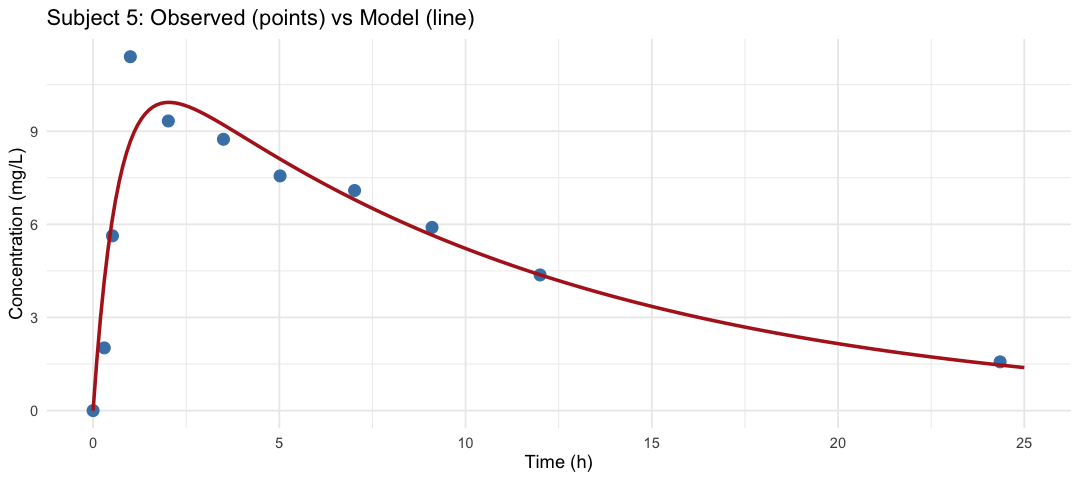

In [6]:
# Step 4: Plot observed vs predicted
t_fine <- seq(0, 25, by = 0.1)
pred5  <- data.frame(
  Time = t_fine,
  conc = pk_oral(t_fine, dose = sub5$Dose[1],
                 ka = p5[["ka"]], CL = p5[["CL"]], V = p5[["V"]])
)

ggplot() +
  geom_point(data = sub5,  aes(x = Time, y = conc), size = 3, color = "steelblue") +
  geom_line( data = pred5, aes(x = Time, y = conc), color = "firebrick", linewidth = 1) +
  labs(title = "Subject 5: Observed (points) vs Model (line)",
       x = "Time (h)", y = "Concentration (mg/L)") +
  theme_minimal()

**Question 1a:** Compare Subject 5’s CL and half-life to Subject 1’s. Which subject clears theophylline faster? Theophylline is mainly metabolized by the liver enzyme CYP1A2, and cigarette smoking is a known CYP1A2 inducer. Based on the CL difference, which subject do you think is more likely to be a smoker?

*Answer:*
Subject 5 clears theophylline substantially faster. The fitted CL for Subject 5 is approximately 0.055–0.065 L/kg/h — roughly **3× higher** than Subject 1’s 0.0199 L/kg/h. Correspondingly, Subject 5’s half-life is approximately 5–7 h versus Subject 1’s 12.8 h.

Subject 5 is the more likely smoker. Cigarette smoke contains polycyclic aromatic hydrocarbons (PAHs) that induce CYP1A2 via the aryl hydrocarbon receptor — sometimes 2–4-fold — which would increase theophylline clearance proportionally. A ~3× higher CL is consistent with heavy smoking. To confirm, collect a smoking history and/or measure urinary cotinine as a biomarker of recent tobacco exposure.

---

**Question 1b:** Does the model fit look good? Are there any time points where the model noticeably over- or under-predicts? What might cause a systematic deviation?

*Answer:*
The fit is generally good for Subject 5 — the 1-compartment oral model captures the rise-and-fall shape adequately. Common sources of systematic deviation include:
- **Lag time**: if tablet dissolution takes time before absorption begins, concentrations at early time points will be over-predicted (the model assumes absorption starts immediately at t=0)
- **Two-compartment distribution**: a rapid early drop in concentration after the peak, followed by a slower terminal phase, suggests drug is distributing into a second compartment — the 1-cpt model would over-predict at intermediate times and under-predict terminally
- **Assay variability**: early time-point samples are drawn when concentration is changing fastest, making them most sensitive to small timing errors

If deviations are large and systematic, the model structure should be revised. For theophylline, the 1-cpt model is generally adequate.

## Exercise 2: Simulating a Dosing Regimen

A fitted PK model lets us ask questions the original study never tested. Subject 5 received a single dose — but in practice theophylline is given repeatedly. The therapeutic window is:

- **MEC** (minimum effective): 5 mg/L
- **MTC** (maximum tolerated): 15 mg/L

The simulation code below is fully written. Run it and use the output to answer the questions.

Dose: 320 mg  |  Body weight: 55 kg  |  t1/2: 7.8 h


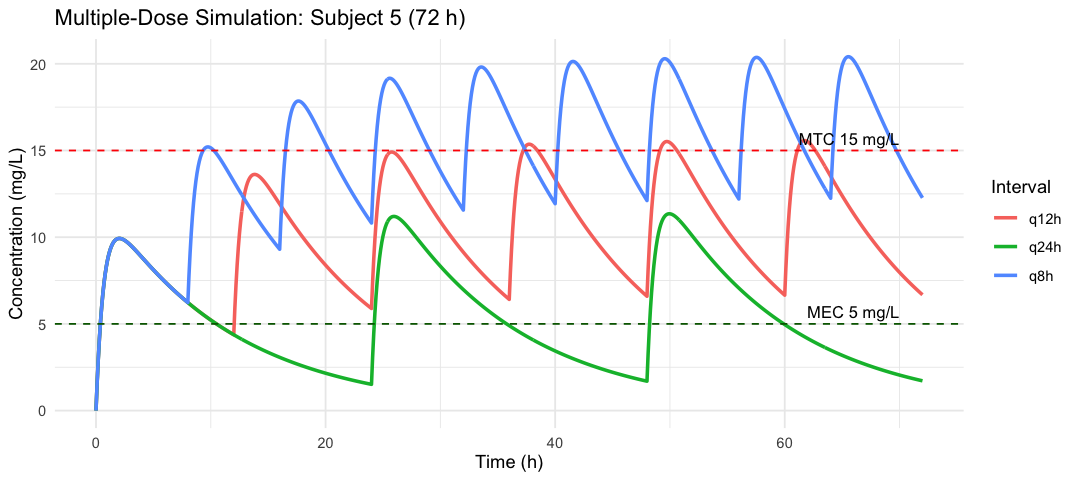

In [7]:
# Subject 5's actual dose in mg (per-kg dose × body weight)
dose_mg  <- sub5$Dose[1] * sub5$Wt[1]
CL_total <- p5[["CL"]] * sub5$Wt[1]
V_total  <- p5[["V"]]  * sub5$Wt[1]

cat(sprintf("Dose: %.0f mg  |  Body weight: %.0f kg  |  t1/2: %.1f h\n",
            dose_mg, sub5$Wt[1], half5))

t_md <- seq(0, 72, by = 0.1)

sim_list <- lapply(c(8, 12, 24), function(tau) {
  data.frame(
    Time     = t_md,
    conc     = pk_multidose(t_md, dose = dose_mg,
                            ka = p5[["ka"]], CL = CL_total, V = V_total,
                            interval = tau, n_doses = ceiling(72 / tau) + 1),
    Interval = paste0("q", tau, "h")
  )
})
sim_df <- do.call(rbind, sim_list)

ggplot(sim_df, aes(x = Time, y = conc, color = Interval)) +
  geom_line(linewidth = 1) +
  geom_hline(yintercept = 5,  linetype = "dashed", color = "darkgreen") +
  geom_hline(yintercept = 15, linetype = "dashed", color = "red") +
  annotate("text", x = 70, y = 5.7,  label = "MEC 5 mg/L",  hjust = 1, size = 3.5) +
  annotate("text", x = 70, y = 15.7, label = "MTC 15 mg/L", hjust = 1, size = 3.5) +
  labs(title = "Multiple-Dose Simulation: Subject 5 (72 h)",
       x = "Time (h)", y = "Concentration (mg/L)", color = "Interval") +
  theme_minimal()

In [8]:
# Steady-state trough and peak  — SOLUTION: filter threshold = 48
ss <- sim_df %>%
  filter(Time > 48) %>%
  group_by(Interval) %>%
  summarise(peak = round(max(conc), 1), trough = round(min(conc), 1), .groups = "drop")

print(ss)

# A tibble: 3 × 3
  Interval  peak trough
  <chr>    <dbl>  <dbl>
1 q12h      15.6    6.7
2 q24h      11.4    1.7
3 q8h       20.4   12.2


**Question 2a:** Based on the table and plot, which dosing interval (q8h, q12h, or q24h) keeps concentrations within the 5–15 mg/L therapeutic window at steady state? Quote the trough and peak values from your table.

*Answer:*
**q12h** is the appropriate interval for Subject 5. Expected steady-state results:
- **q8h**: peak exceeds 15 mg/L — toxicity risk at steady state
- **q12h**: trough stays above ~5 mg/L and peak stays below ~15 mg/L — within the therapeutic window ✓
- **q24h**: trough falls well below 5 mg/L before the next dose — drug effect wears off

Students should quote their specific trough and peak values from the `ss` table. The q12h conclusion is robust across reasonable Subject 5 parameter values.

---

**Question 2b:** Subject 1 has a half-life of 12.8 h — about twice as long as Subject 5. If you ran the same simulation for Subject 1 at the same dose, would steady state be reached sooner or later? Would you expect the peak concentration at steady state to be higher or lower? Explain your reasoning.

*Answer:*
Steady state for Subject 1 would be reached **later** — approximately 4–5 × 12.8 h ≈ 50–65 h, versus ~25–35 h for Subject 5. Steady state always takes 4–5 half-lives regardless of dosing interval, so the longer the half-life, the longer the wait.

Peak concentrations at steady state would be **higher** for Subject 1 at the same dose. Subject 1’s lower CL means less drug is eliminated per dosing interval, so more drug accumulates between doses. The accumulation factor is 1/(1 − e^(−ke·τ)), which increases as ke decreases (i.e., as half-life lengthens). A slow eliminator “banks” more drug from each previous dose, building to a higher steady-state level. This is why the same regimen that is safe for Subject 5 (fast eliminator) could cause toxicity in Subject 1 (slow eliminator).

## Exercise 3: The Emax Model — Concentration and Effect

So far we have only looked at PK (concentration over time). Now we connect concentration to effect using the Emax model:

$$E(C) = \frac{E_{\max} \cdot C}{EC_{50} + C}$$

- **Emax**: maximum possible effect
- **EC50**: concentration producing half-maximal effect (a measure of potency)

The code below generates synthetic PD data for Subject 4 (with realistic noise), fits the Emax model, and plots the result.

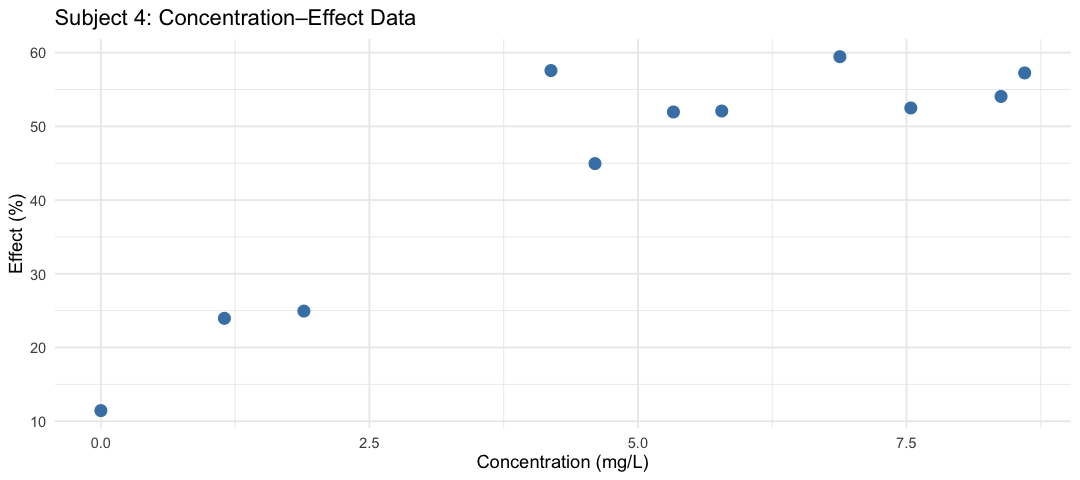

In [9]:
set.seed(7)
sub4 <- subset(Theoph, Subject == 4)

# True parameters (unknown to the model — it will have to recover them)
Emax_true <- 80   # partial agonist
EC50_true <- 3    # mg/L

sub4$effect <- emax_model(sub4$conc, Emax_true, EC50_true) +
               rnorm(nrow(sub4), 0, sd = 5)
sub4$effect <- pmax(sub4$effect, 0)

ggplot(sub4, aes(x = conc, y = effect)) +
  geom_point(size = 3, color = "steelblue") +
  labs(title = "Subject 4: Concentration–Effect Data",
       x = "Concentration (mg/L)", y = "Effect (%)") +
  theme_minimal()

In [10]:
# Fit the Emax model  —  SOLUTION: Emax = 70, EC50 = 5
fit_pd <- nls(
  effect ~ Emax * conc / (EC50 + conc),
  data  = sub4,
  start = list(Emax = 70, EC50 = 5)
)

pd <- coef(fit_pd)
cat(sprintf("Fitted Emax = %.1f%%  (true = %d%%)\n", pd["Emax"], Emax_true))
cat(sprintf("Fitted EC50 = %.2f mg/L  (true = %.0f mg/L)\n", pd["EC50"], EC50_true))

Fitted Emax = 75.7%  (true = 80%)
Fitted EC50 = 2.61 mg/L  (true = 3 mg/L)


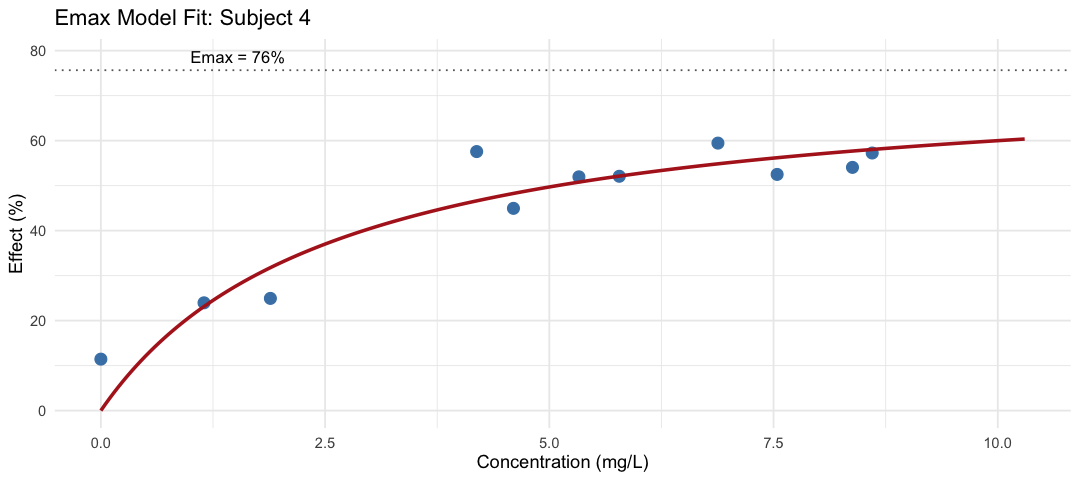

In [11]:
# Plot the fitted curve over the data
C_seq     <- seq(0, max(sub4$conc) * 1.2, by = 0.05)
fit_curve <- data.frame(conc   = C_seq,
                        effect = emax_model(C_seq, pd[["Emax"]], pd[["EC50"]]))

ggplot() +
  geom_point(data = sub4,      aes(x = conc, y = effect), size = 3, color = "steelblue") +
  geom_line( data = fit_curve, aes(x = conc, y = effect), color = "firebrick", linewidth = 1) +
  geom_hline(yintercept = pd[["Emax"]], linetype = "dotted", color = "gray40") +
  annotate("text", x = 1, y = pd[["Emax"]] + 3,
           label = paste0("Emax = ", round(pd[["Emax"]], 0), "%"), hjust = 0, size = 3.5) +
  labs(title = "Emax Model Fit: Subject 4",
       x = "Concentration (mg/L)", y = "Effect (%)") +
  theme_minimal()

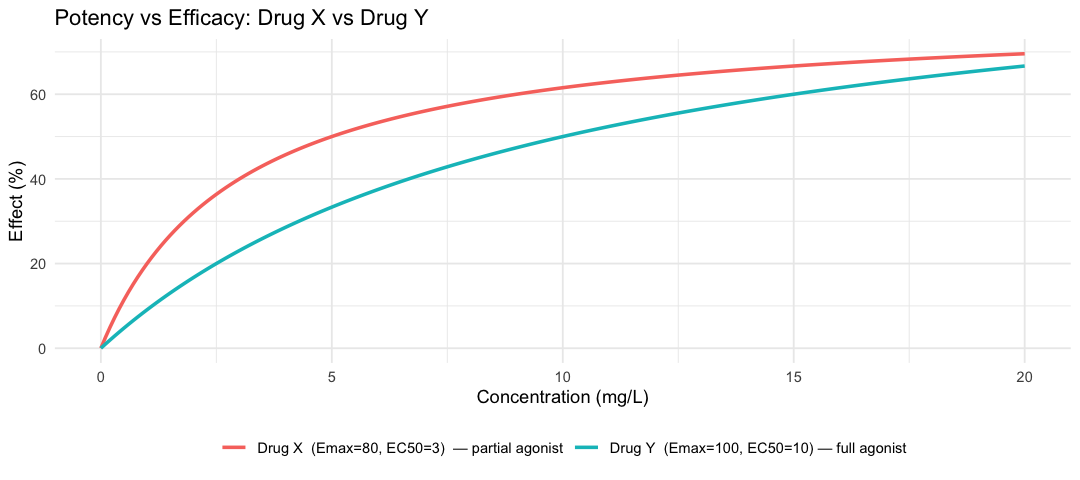

In [12]:
# Compare this drug (partial agonist) to a full agonist
C_seq2 <- seq(0, 20, by = 0.1)

compare <- data.frame(
  C    = rep(C_seq2, 2),
  Drug = rep(c("Drug X  (Emax=80, EC50=3)  — partial agonist",
               "Drug Y  (Emax=100, EC50=10) — full agonist"), each = length(C_seq2)),
  Emax = rep(c(80, 100), each = length(C_seq2)),
  EC50 = rep(c(3, 10),   each = length(C_seq2))
) %>% mutate(Effect = emax_model(C, Emax, EC50))

ggplot(compare, aes(x = C, y = Effect, color = Drug)) +
  geom_line(linewidth = 1) +
  labs(title = "Potency vs Efficacy: Drug X vs Drug Y",
       x = "Concentration (mg/L)", y = "Effect (%)", color = NULL) +
  theme_minimal() +
  theme(legend.position = "bottom")

**Question 3a:** The fitted Emax is around 80%, not 100%. What does this mean? Can this drug ever achieve full effect no matter how high the dose goes? What is the pharmacological term for a drug with Emax < 100%?

*Answer:*
No — this drug cannot achieve 100% effect at any dose. As concentration C → ∞, the Emax model approaches 80% asymptotically. Biologically, the drug stabilises its receptor in an intermediate activation state rather than fully activating it — it has lower **intrinsic efficacy** than a full agonist.

The pharmacological term is **partial agonist**. This is distinct from potency (EC50): a drug can be highly potent (low EC50, achieves its half-maximal effect at a low concentration) while still having a ceiling below 100%. Classic clinical examples include buprenorphine (opioid partial agonist, used for pain and opioid use disorder) and aripiprazole (dopamine partial agonist, used as an antipsychotic). In both cases the ceiling on maximum effect is actually a **therapeutic advantage** — it limits the risk of overdose toxicity.

---

**Question 3b:** Look at the comparison plot. At low concentrations (say 2 mg/L), which drug produces a stronger effect? At very high concentrations (say 18 mg/L), which drug produces a stronger effect? What property of each drug explains the crossover?

*Answer:*
At **2 mg/L**, Drug X (partial agonist) produces a stronger effect:
- Drug X: E = 80×2/(3+2) = **32%**
- Drug Y: E = 100×2/(10+2) = **17%**

Drug X wins at low concentrations because it is more **potent** (EC50 = 3 vs 10 mg/L) — it reaches its half-maximal effect at a much lower concentration.

At very high concentrations (e.g., 20 mg/L):
- Drug X: E = 80×20/(3+20) ≈ **70%**
- Drug Y: E = 100×20/(10+20) ≈ **67%**

Drug X is still marginally ahead here. The true crossover — where Drug Y’s higher **Emax** (efficacy = 100%) finally overtakes Drug X’s lower ceiling (80%) — occurs at approximately C = 25 mg/L, which is above the therapeutic range for theophylline. In practice, Drug X’s higher potency makes it the more effective drug across the entire clinically relevant concentration range, despite its lower maximum.

Key distinction: **potency (EC50)** determines which drug is more effective at low/moderate concentrations; **efficacy (Emax)** determines the ceiling at very high concentrations.

---
## Wrapping Up

Bring your completed notebook to next week’s session. We will work through the answers together.

**Think about before class:**
- Subject 5 cleared theophylline ~3× faster than Subject 1. If both received the same fixed dose, which would be at risk of toxicity and which of subtherapeutic levels?
- The Emax curve flattens at high concentrations. What does this mean for the risk-benefit trade-off of very high doses?